# Naive Bayes Baseline

Goal:

Train a Multinomial Naive Bayes classifier on TF-IDF features and compare it against Logistic Regression.

This establishes a baseline and helps justify model selection.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np

PROJECT_ROOT = "/content/drive/MyDrive/emotion_sentiment_fusion_detector"

X = np.load(
    f"{PROJECT_ROOT}/data/tfidf/X.npy"
)

y = np.load(
    f"{PROJECT_ROOT}/data/tfidf/y.npy"
)

print(X.shape)
print(y.shape)

(5000, 3000)
(5000,)


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Train Multinomial Naive Bayes

In [4]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(
    X_train,
    y_train
)

MultinomialNB()

In [5]:
y_pred_nb = nb_model.predict(
    X_test
)

In [6]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

nb_accuracy = accuracy_score(
    y_test,
    y_pred_nb
)

nb_precision = precision_score(
    y_test,
    y_pred_nb
)

nb_recall = recall_score(
    y_test,
    y_pred_nb
)

nb_f1 = f1_score(
    y_test,
    y_pred_nb
)

print("Accuracy :", nb_accuracy)
print("Precision:", nb_precision)
print("Recall   :", nb_recall)
print("F1       :", nb_f1)

Accuracy : 0.842
Precision: 0.9057971014492754
Recall   : 0.7591093117408907
F1       : 0.8259911894273128


In [7]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_nb
    )
)

              precision    recall  f1-score   support

           0       0.80      0.92      0.86       506
           1       0.91      0.76      0.83       494

    accuracy                           0.84      1000
   macro avg       0.85      0.84      0.84      1000
weighted avg       0.85      0.84      0.84      1000



In [8]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_nb
)

cm

array([[467,  39],
       [119, 375]])

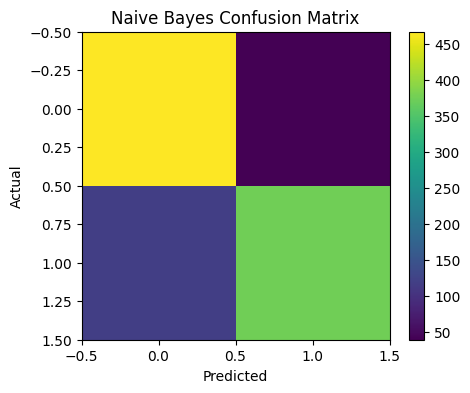

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

plt.imshow(cm)

plt.colorbar()

plt.title("Naive Bayes Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## Model Comparison

In [10]:
import pandas as pd

comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Naive Bayes"
    ],

    "Precision":[
        0.887,
        nb_precision
    ],

    "Recall":[
        0.812,
        nb_recall
    ],

    "F1":[
        0.848,
        nb_f1
    ]
})

comparison

,Model,Precision,Recall,F1
0,Logistic Regression,0.887000,0.812000,0.848000
1,Naive Bayes,0.905797,0.759109,0.825991


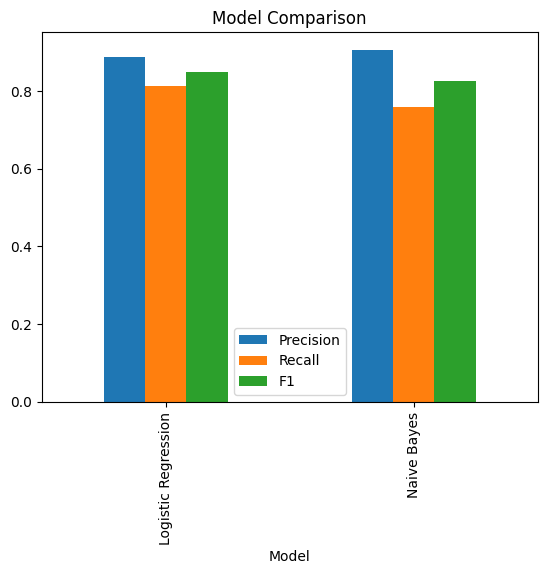

In [11]:
comparison.set_index(
    "Model"
).plot(
    kind="bar"
)

plt.title(
    "Model Comparison"
)

plt.show()

# Conclusion

If Logistic Regression achieves a higher F1 score, it will be selected as the NLP model for the final system.

Reasons:

- Better generalization
- Better handling of correlated features
- Strong performance on sparse TF-IDF vectors

# Sentiment Error Analysis

Goal:

Understand where the model fails.

Focus:

- False Positives
- False Negatives
- Negation
- Mixed Sentiment
- Sarcasm

In [15]:
import pandas as pd
import numpy as np
import joblib

PROJECT_ROOT = "/content/drive/MyDrive/emotion_sentiment_fusion_detector"

df = pd.read_csv(
    f"{PROJECT_ROOT}/data/imdb/imdb_processed.csv"
)

model = joblib.load(
    f"{PROJECT_ROOT}/models/nlp/logistic_regression_tfidf.pkl"
)

X = np.load(
    f"{PROJECT_ROOT}/data/tfidf/X.npy"
)

y = np.load(
    f"{PROJECT_ROOT}/data/tfidf/y.npy"
)

In [17]:

df = df.head(5000).copy()

In [20]:
print(df.shape)

(5000, 3)


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X,
    y,
    np.arange(len(df)),
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
y_pred = model.predict(X_test)

In [22]:
false_positive_idx = np.where(
    (y_test == 0) &
    (y_pred == 1)
)[0]

len(false_positive_idx)

51

In [23]:
for idx in false_positive_idx[:5]:

    review_index = idx_test[idx]

    print("="*100)

    print(
        df.iloc[review_index]["review"][:1500]
    )

    print("\nACTUAL: NEGATIVE")
    print("PREDICTED: POSITIVE")

I've always found the dilettante Man Ray and his artistic efforts to be deeply pretentious, and I've never understood why his work attracts so much attention. Apart from his Rayographs (which he invented by accident, and which are merely direct-contact photo prints), his one real contribution to culture seems to be that he was the first photographer to depict female nudity in a manner that was accepted as art rather than as porn. But surely this had to happen eventually, and there's no real reason why Ray deserves the credit. The critical reaction to Man Ray reminds me of the story about the Emperor's New Clothes.<br /><br />"L'Étoile de merde" ... whoops, "de mer" ... features a lot of blurry photography and a recurring visual theme of a starfish, which is never explained. Starfishes have the fascinating ability to regenerate lost limbs -- and even to regenerate entire duplicate bodies -- but, if that has anything to do with this movie's theme, Ray neglects to say so. I was much more 

In [24]:
false_negative_idx = np.where(
    (y_test == 1) &
    (y_pred == 0)
)[0]

len(false_negative_idx)

93

In [25]:
for idx in false_negative_idx[:5]:

    review_index = idx_test[idx]

    print("="*100)

    print(
        df.iloc[review_index]["review"][:1500]
    )

    print("\nACTUAL: POSITIVE")
    print("PREDICTED: NEGATIVE")

No matter how much it hurts me to say this,the movie is not as good as it could have been.Maybe I was misled by the countless exaggerated reviews here on IMDb,but I expected so much more...<br /><br />Sure,the idea is a good one,the violent scenes and the camera-work are outstanding,the imagination of genius Dario is breathtaking, but the movie is "soiled" by a couple of mistakes that I find unforgivable. First of all, am I one of the few people who feel that the Heavy Metal music played in the most intense scenes simply rips the atmosphere apart??? With a different kind of music (Goblin????) during the "needle" scenes,it would have been SOOOO intense!... Instead,the soundtrack destroys any chance for tension... Secondly, the final killing scene and the last few moments of the movie are simply silly and uninspired. I don't want to say "amateurish", cause I love Argento's movies.The ending left me feeling empty.Talk about a final impression! This is hardly what happens in most of Dario'

## Error Categories

Look for:

1. Negation

Example:
"Not bad at all"

2. Mixed sentiment

Example:
"Started strong but ended poorly"

3. Sarcasm

Example:
"Yeah, this masterpiece wasted two hours of my life"

4. Long reviews

Example:
Multiple sentiment shifts inside one review.

In [26]:
error_examples = []

for idx in false_positive_idx[:10]:

    review_index = idx_test[idx]

    error_examples.append(
        {
            "type":"False Positive",
            "review":df.iloc[review_index]["review"][:500]
        }
    )

for idx in false_negative_idx[:10]:

    review_index = idx_test[idx]

    error_examples.append(
        {
            "type":"False Negative",
            "review":df.iloc[review_index]["review"][:500]
        }
    )

error_df = pd.DataFrame(error_examples)

error_df.head()

,type,review
0,False Positive,I've always found the dilettante Man Ray and h...
1,False Positive,Directed by Diane Keaton and adapted from a bo...
2,False Positive,"A 'Wes Craven presents' movie from 1995, direc..."
3,False Positive,This had a great cast with big-name stars like...
4,False Positive,*SPOILERS*<br /><br />I'm sure back when this ...


# Findings

Observed failure modes:

- Negation handling
- Mixed sentiment reviews
- Sarcastic reviews
- Reviews containing conflicting emotional signals

These limitations motivate richer semantic representations such as word embeddings.

# Error Analysis Findings

## False Negatives

Common patterns:

- Reviews containing negation terms such as:
  - not
  - never
  - hardly

- Reviews with indirect positive sentiment:
  - "not bad"
  - "hardly disappointing"

- Sarcastic or subtle positive reviews that did not contain strongly positive vocabulary.

Reason:

TF-IDF primarily counts important words and does not fully understand context or word order. Phrases such as "not bad" may be interpreted similarly to "bad".

---

## False Positives

Common patterns:

- Long reviews containing multiple sentiment shifts.
- Reviews expressing both positive and negative opinions.
- Nuanced reviews where the final sentiment depends on context rather than individual words.

Example pattern:

"The acting was excellent, but the story completely fell apart."

Reason:

TF-IDF treats words independently and cannot effectively capture relationships between different parts of a sentence.

---

## Overall Conclusion

Main failure modes:

1. Negation
2. Sarcasm
3. Mixed sentiment reviews
4. Long context-dependent reviews

These limitations motivate the use of semantic word embeddings such as GloVe.